In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [14]:
import os
import librosa
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import wavfile
import warnings
warnings.filterwarnings("ignore")

In [15]:
ls /kaggle/input/dataset

link_to_gcp_credits_form.txt*  sample_submission/  test/  train/


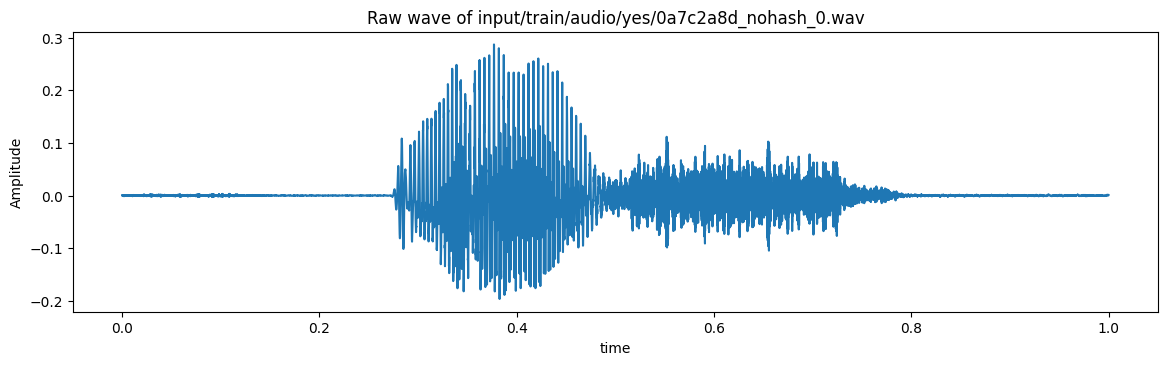

In [17]:
train_audio_path = '/kaggle/input/dataset/train/train/audio/'
samples, sample_rate = librosa.load(train_audio_path+'yes/0a7c2a8d_nohash_0.wav', sr = 16000)
fig = plt.figure(figsize=(14, 8))
ax1 = fig.add_subplot(211)
ax1.set_title('Raw wave of ' + 'input/train/audio/yes/0a7c2a8d_nohash_0.wav')
ax1.set_xlabel('time')
ax1.set_ylabel('Amplitude')
ax1.plot(np.linspace(0, sample_rate/len(samples), sample_rate), samples)

In [18]:
ipd.Audio(samples, rate=sample_rate)

In [19]:
print(sample_rate)

16000


In [24]:
samples_resampled = librosa.resample(samples, orig_sr=sample_rate, target_sr=8000)
ipd.Audio(samples_resampled, rate=8000)


In [25]:
labels = os.listdir(train_audio_path)


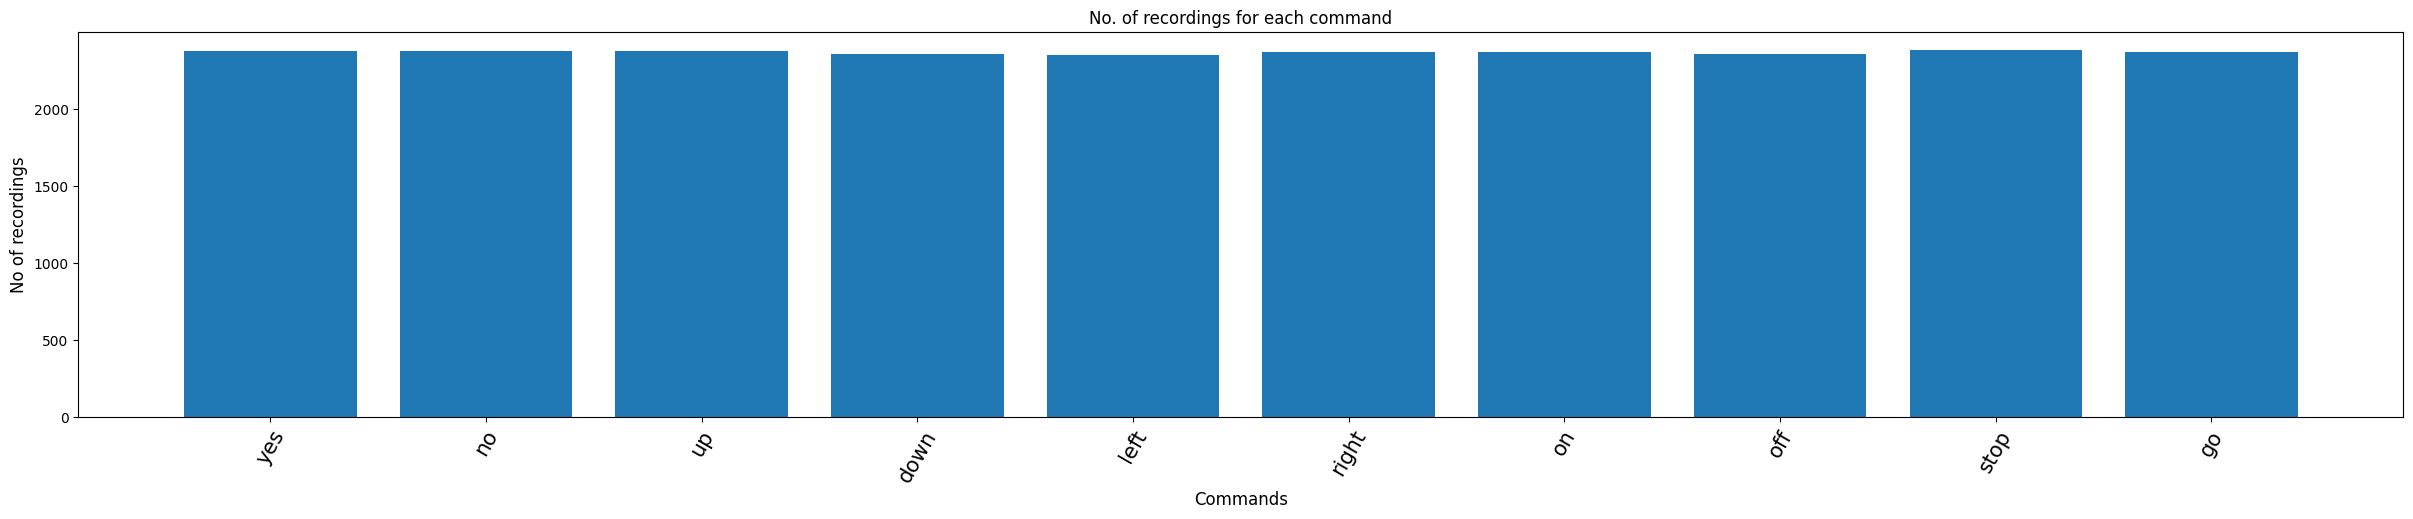

In [27]:
no_of_recordings = []
for label in labels:
    waves = [f for f in os.listdir(train_audio_path+'/'+label) if f.endswith('.wav')]
    no_of_recordings.append(len(waves))

#plot
plt.figure(figsize=(30,5))
index = np.arange(len(labels))
plt.bar(index, no_of_recordings)
plt.xlabel('Commands', fontsize=12)
plt.ylabel('No of recordings', fontsize=12)
plt.xticks(index, labels, fontsize=15, rotation=60)
plt.title('No. of recordings for each command')
plt.show()




(array([1.5000e+01, 3.0000e+01, 4.4000e+01, 1.3800e+02, 1.3600e+02,
        1.7900e+02, 3.6600e+02, 4.3400e+02, 5.9300e+02, 2.1747e+04]),
 array([0.418 , 0.4762, 0.5344, 0.5926, 0.6508, 0.709 , 0.7672, 0.8254,
        0.8836, 0.9418, 1.    ]),
 <BarContainer object of 10 artists>)

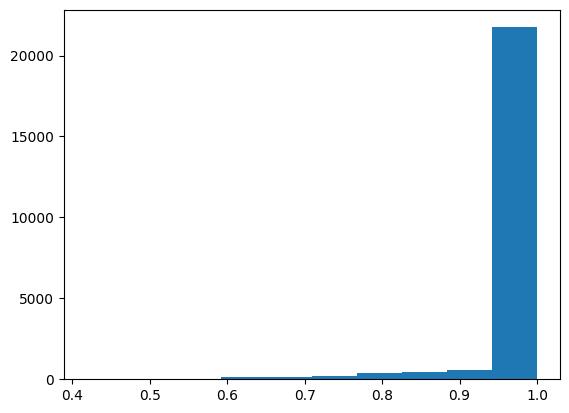

In [28]:
labels=["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
duration_of_recordings=[]
for label in labels:
      waves = [f for f in os.listdir(train_audio_path+'/'+label) if f.endswith('.wav')]
      for wav in waves:
        sample_rate, samples = wavfile.read(train_audio_path + '/' + label + '/' + wav)
        duration_of_recordings.append(float(len(samples)/sample_rate))

plt.hist(np.array(duration_of_recordings))

In [30]:
train_audio_path = '/kaggle/input/dataset/train/train/audio/'
all_wave = []
all_label = []
for label in labels:
    print(label)
    waves = [f for f in os.listdir(train_audio_path + '/'+ label) if f.endswith('.wav')]
    for wav in waves:
        samples, sample_rate = librosa.load(train_audio_path + '/' + label + '/' + wav, sr = 16000)
        samples = librosa.resample(samples, orig_sr=sample_rate, target_sr=8000)
        if(len(samples)== 8000) :
            all_wave.append(samples)
            all_label.append(label)

yes
no
up
down
left
right
on
off
stop
go


In [31]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(all_label)
classes = list(le.classes_)


In [32]:
from tensorflow.keras import utils as utils
y = utils.to_categorical(y, num_classes = len(labels))


In [33]:
all_wave = np.array(all_wave).reshape(-1, 8000, 1)


In [34]:
from sklearn.model_selection import train_test_split
x_tr, x_val, y_tr, y_val = train_test_split(np.array(all_wave), np.array(y), stratify=y, test_size=0.2, random_state=777, shuffle=True)

In [35]:
from tensorflow import keras as keras

In [36]:
import tensorflow.keras as keras
from tensorflow.keras import Input, layers
from tensorflow.keras import backend as K

In [37]:
K.clear_session()

In [40]:
inputs = Input(shape=(8000,1))
#First Conv1D layer
conv = layers.Conv1D(8,13, padding='valid', activation='relu',strides=1)(inputs)
conv = layers.MaxPooling1D(3)(conv)
conv = layers.Dropout(0.3)(conv)
#Second Conv1D layer
conv = layers.Conv1D(16, 11, padding='valid', activation='relu',strides=1)(conv)
conv = layers.MaxPooling1D(3)(conv)
conv = layers.Dropout(0.3)(conv)
#Third Conv1D layer
conv = layers.Conv1D(32, 9, padding='valid', activation='relu', strides=1)(conv)
conv = layers.MaxPooling1D(3)(conv)
conv = layers.Dropout(0.3)(conv)
#Fourth Conv1D layer
conv = layers.Conv1D(64, 7, padding='valid', activation='relu', strides=1)(conv)
conv = layers.MaxPooling1D(3)(conv)
conv = layers.Dropout(0.3)(conv)
#Flatten layer
conv = layers.Flatten()(conv)
# Dense Layer 1
conv = layers.Dense(256, activation='relu')(conv)
conv = layers.Dropout(0.3)(conv)
#Dense Layer 2
conv = layers.Dense(128, activation='relu')(conv)
conv = layers.Dropout(0.3)(conv)
outputs = layers.Dense(len(labels), activation='softmax')(conv)
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 8000, 1)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ (None, 7988, 8)             │             112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_4 (MaxPooling1D)       │ (None, 2662, 8)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 2662, 8)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 2652, 16)            │           1,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_5 (MaxPooling1D)       │ (None, 884, 16)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 884, 16)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_6 (Conv1D)                    │ (None, 876, 32)             │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_6 (MaxPooling1D)       │ (None, 292, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 292, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_7 (Conv1D)                    │ (None, 286, 64)             │          14,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_7 (MaxPooling1D)       │ (None, 95, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 95, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 6080)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       1,556,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,611,498 (6.15 MB)

 Trainable params: 1,611,498 (6.15 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [43]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [45]:
es = EarlyStopping(monitor = 'val_loss', mode = 'min', verbose = 1, patience = 10, min_delta = 0.00001)
mc = ModelCheckpoint('best_model.keras', monitor = 'val_acc', verbose = 1, save_best_only = True, mode = 'max')

In [47]:
history=model.fit(x_tr, y_tr ,epochs=100, callbacks=[es,mc], batch_size=32,validation_data=(x_val,y_val))

Epoch 1/100
304/533 ━━━━━━━━━━━━━━━━━━━━ 27s 121ms/step - accuracy: 0.1183 - loss: 2.2873

KeyboardInterrupt: 

In [ ]:
from matplotlib import pyplot
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()

In [ ]:
from keras.models import load_model
model = load_model('best_model.keras')


In [ ]:
def predict(audio):
    prob=model.predict(audio.reshape(1,8000,1))
    index=np.argmax(prob[0])
    return classes[index]

In [ ]:
import random
index=random.randint(0,len(x_val)-1)
samples=x_val[index].ravel()
print("Audio:",classes[np.argmax(y_val[index])])
ipd.Audio(samples, rate=8000)

In [ ]:
print("Text:",predict(samples))

In [ ]:
pip install sounddevice

In [ ]:
pip install soundfile

In [ ]:
import sounddevice as sd
import soundfile as sf
samplerate = 16000
duration = 1 # seconds
filename = 'yes.wav'
print("start")
mydata = sd.rec(int(samplerate * duration), samplerate=samplerate,
channels=1, blocking=True)
print("end")
sd.wait()
sf.write(filename, mydata, samplerate)

In [ ]:
ls yes.wav

In [ ]:
#Load the recorded wav file..
samples, sample_rate = librosa.load('yes.wav', sr = 16000)

In [ ]:
ipd.Audio(samples, rate=sample_rate)

In [ ]:
#reading the voice commands
samples, sample_rate = librosa.load('yes.wav', sr = 16000)
samples = librosa.resample(samples, sample_rate, 8000)
ipd.Audio(samples,rate=8000)

In [ ]:
#converting voice commands to text
predict(samples)